# Sequential question-plus-choices length ablation for MMLU-PT

**Research question.** After applying the existing question- and choice-length limits, how does an additional maximum threshold on their combined word count affect retention and representation?

## Abstract

A question and its answer choices jointly determine the size of a multiple-choice example. This notebook studies a third, sequential length filter on their combined word count. It first applies the existing inclusive limits of 4–1,000 words for the question and 300 words for all choices, then ablates a combined maximum N over the remaining population. The analysis reports incremental and cumulative retention, subgroup effects, component relationships, and deterministic boundary samples. Based on this evidence, the selected operating point is an inclusive N of 1,000 words.

In [1]:
from __future__ import annotations

import hashlib
import platform
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from nemo_curator.stages.text.filters.heuristic import WordCountFilter

SEED = 42
QUESTION_MIN_WORDS = 4
QUESTION_MAX_WORDS = 1_000
CHOICES_MAX_WORDS = 300
SELECTED_TOTAL_MAX_WORDS = 1_000
TOTAL_MAX_THRESHOLDS = [300, 400, 500, 600, 700, 750, 800, 850, 900, 950, 1_000, 1_050, 1_100, 1_150, 1_200]
CANDIDATE_THRESHOLDS = [750, 800, 850, 900, 950, 1_000, 1_050, 1_100, 1_150, 1_200]
NEUTRAL_MAX = 1_000_000

sns.set_theme(context="paper", style="whitegrid", font_scale=1.1)
pd.set_option("display.max_colwidth", 180)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

def find_repo_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError("Could not locate the repository root from the current directory.")

REPO_ROOT = find_repo_root(Path.cwd())
INPUT_DIR = REPO_ROOT / "output" / "03 - pre-word-filter"
print(f"Repository: {REPO_ROOT}")
print(f"Input: {INPUT_DIR}")
print(f"Python: {platform.python_version()}")

Repository: /home/aluno_paulosantana/repositories/mmlu-pt
Input: /home/aluno_paulosantana/repositories/mmlu-pt/output/03 - pre-word-filter
Python: 3.12.3


## 1. Data and reproducibility

The input is the public-field projection produced after structural MCQA validation and before length filtering. Files are sorted before loading and hashing. The SHA-256 fingerprint identifies the exact materialized snapshot analyzed below.

In [2]:
EXPECTED_COLUMNS = [
    "exam",
    "exam_edition",
    "exam_url",
    "num",
    "question",
    "choices",
    "answer",
    "academic_level",
]

input_files = sorted(INPUT_DIR.glob("*.jsonl"))
if not input_files:
    raise FileNotFoundError(
        f"No JSONL files found in {INPUT_DIR}. Run src/mmlu_pt/pipeline_minimal.py first."
    )

frames = []
for path in input_files:
    frame = pd.read_json(path, lines=True, convert_dates=False)
    frame["_partition_file"] = path.name
    frames.append(frame)

data = pd.concat(frames, ignore_index=True)
missing_columns = sorted(set(EXPECTED_COLUMNS) - set(data.columns))
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")
if data.empty:
    raise ValueError("The pre-word-filter dataset is empty.")
if data["question"].isna().any():
    raise ValueError("The question field contains null values.")

def has_valid_choices(value: object) -> bool:
    return (
        isinstance(value, list)
        and len(value) in {4, 5}
        and all(isinstance(choice, str) and bool(choice.strip()) for choice in value)
    )

invalid_choices = ~data["choices"].map(has_valid_choices)
if invalid_choices.any():
    raise ValueError(f"Found {int(invalid_choices.sum()):,} records with invalid choices.")

digest = hashlib.sha256()
for path in input_files:
    digest.update(path.name.encode("utf-8"))
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)

snapshot = pd.Series(
    {
        "files": len(input_files),
        "records": len(data),
        "exams": data["exam"].nunique(),
        "exam_editions": data["exam_edition"].nunique(dropna=True),
        "academic_levels": data["academic_level"].nunique(),
        "sha256": digest.hexdigest(),
    },
    name="value",
)
display(snapshot.to_frame())

,value
files,19
records,41988
exams,17
exam_editions,1045
academic_levels,2
sha256,2a7ded87ec71df2f3d304e392ea3c1525ba432bcd9d4566f6a82525bc3360caa


## 2. Measurement and sequential baseline

Word counts use the exact NeMo Curator implementation used by the pipeline. Choices are measured individually and summed; the combined count is the question count plus the choice total. The baseline for the N ablation contains only records retained by the inclusive question and choice filters.

In [3]:
word_counter = WordCountFilter(min_words=0, max_words=NEUTRAL_MAX, lang="pt")

data["question_word_count"] = data["question"].map(word_counter.score_document).astype(int)
data["choice_word_counts"] = data["choices"].map(
    lambda choices: [int(word_counter.score_document(choice)) for choice in choices]
)
data["choices_word_count"] = data["choice_word_counts"].map(sum).astype(int)
data["total_word_count"] = data["question_word_count"] + data["choices_word_count"]
data["question_share"] = data["question_word_count"] / data["total_word_count"]

assert (data["total_word_count"] <= NEUTRAL_MAX).all(), "The neutral maximum unexpectedly removes records."

question_mask = data["question_word_count"].between(
    QUESTION_MIN_WORDS,
    QUESTION_MAX_WORDS,
    inclusive="both",
)
question_and_choices_mask = question_mask & (data["choices_word_count"] <= CHOICES_MAX_WORDS)
eligible = data.loc[question_and_choices_mask].copy()

funnel = pd.DataFrame(
    [
        {
            "stage": "Structurally valid input",
            "retained": len(data),
            "removed_from_previous": 0,
            "retention_from_input_pct": 100.0,
        },
        {
            "stage": "Inclusive question filter (4–1,000)",
            "retained": int(question_mask.sum()),
            "removed_from_previous": int((~question_mask).sum()),
            "retention_from_input_pct": 100 * question_mask.mean(),
        },
        {
            "stage": "Inclusive choices filter (≤300)",
            "retained": int(question_and_choices_mask.sum()),
            "removed_from_previous": int((question_mask & ~question_and_choices_mask).sum()),
            "retention_from_input_pct": 100 * question_and_choices_mask.mean(),
        },
    ]
)
display(funnel)

,stage,retained,removed_from_previous,retention_from_input_pct
0,Structurally valid input,41988,0,100.000
1,"Inclusive question filter (4–1,000)",41731,257,99.388
2,Inclusive choices filter (≤300),41690,41,99.290


In [4]:
percentiles = [0.001, 0.005, 0.01, 0.025, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.975, 0.99, 0.995, 0.999]
overall = eligible[
    ["question_word_count", "choices_word_count", "total_word_count", "question_share"]
].describe(percentiles=percentiles).T

level_summary = (
    eligible.groupby("academic_level")["total_word_count"]
    .agg(records="size", mean="mean", median="median", q95=lambda s: s.quantile(0.95), q99=lambda s: s.quantile(0.99), maximum="max")
    .sort_values("records", ascending=False)
)
exam_summary = (
    eligible.groupby("exam")["total_word_count"]
    .agg(records="size", mean="mean", median="median", q95=lambda s: s.quantile(0.95), q99=lambda s: s.quantile(0.99), maximum="max")
    .sort_values("records", ascending=False)
)
display(
    Markdown("### Eligible population"), overall,
    Markdown("### Academic level"), level_summary,
    Markdown("### Exam"), exam_summary,
)

### Eligible population

,count,mean,std,min,0.1%,0.5%,1%,2.5%,5%,10%,25%,50%,75%,90%,95%,97.5%,99%,99.5%,99.9%,max
question_word_count,"41,690.000",110.848,119.863,4.000,4.000,4.000,4.000,6.000,8.000,11.000,31.000,81.000,147.000,235.000,304.000,430.000,685.220,777.555,947.622,999.000
choices_word_count,"41,690.000",52.421,44.514,4.000,4.000,4.000,4.000,5.000,5.000,8.000,16.000,40.000,77.000,114.000,138.000,162.000,193.000,218.000,263.311,297.000
total_word_count,"41,690.000",163.269,122.464,9.000,14.000,20.000,23.000,31.000,39.000,53.000,86.000,137.000,205.000,285.000,364.000,484.000,727.110,836.000,992.311,"1,160.000"
question_share,"41,690.000",0.609,0.290,0.013,0.024,0.034,0.043,0.065,0.094,0.145,0.374,0.673,0.881,0.938,0.956,0.968,0.978,0.986,0.993,0.996


### Academic level

,records,mean,median,q95,q99,maximum
academic_level,,,,,,
undergraduate,31860,159.561,135.000,349.000,630.000,1160
high_school,9830,175.290,142.000,436.550,883.130,1077


### Exam

,records,mean,median,q95,q99,maximum
exam,,,,,,
ENADE,10785,211.962,204.000,373.000,497.000,789
OAB,10251,113.472,102.000,232.000,292.000,459
BNDES,4060,170.245,102.000,650.000,862.000,1160
ENEM,2688,146.861,134.000,282.000,352.130,488
OBI,2301,162.002,158.000,249.000,312.000,364
FUVEST,1659,145.605,122.000,326.100,455.420,903
RESIDENCIA_USP_UNICAMP,1574,89.822,80.000,194.000,276.540,447
POSCOMP,1305,100.237,89.000,203.800,279.960,370
REVALIDA,1195,159.901,149.000,278.300,357.060,494


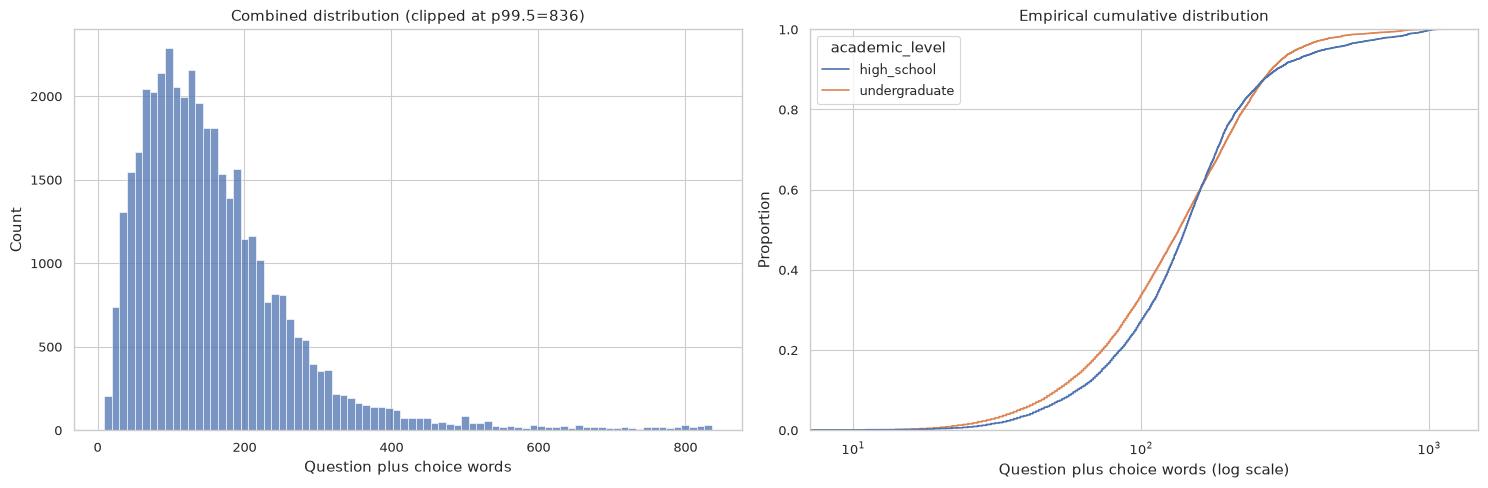

In [5]:
q995 = int(np.ceil(eligible["total_word_count"].quantile(0.995)))
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(
    data=eligible[eligible["total_word_count"] <= q995],
    x="total_word_count",
    bins=80,
    ax=axes[0],
)
axes[0].set(
    title=f"Combined distribution (clipped at p99.5={q995})",
    xlabel="Question plus choice words",
)
sns.ecdfplot(data=eligible, x="total_word_count", hue="academic_level", ax=axes[1])
axes[1].set(
    xscale="log",
    title="Empirical cumulative distribution",
    xlabel="Question plus choice words (log scale)",
)
plt.tight_layout()
plt.show()

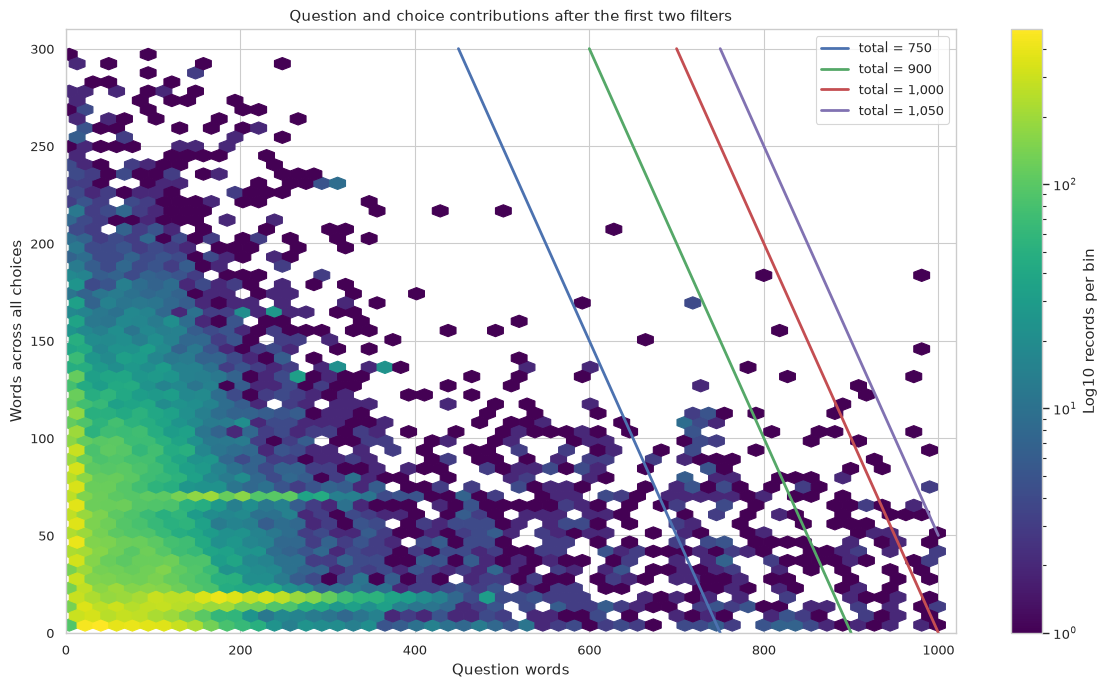

In [6]:
fig, ax = plt.subplots(figsize=(12, 7))
hexbin = ax.hexbin(
    eligible["question_word_count"],
    eligible["choices_word_count"],
    gridsize=55,
    bins="log",
    mincnt=1,
    cmap="viridis",
)
fig.colorbar(hexbin, ax=ax, label="Log10 records per bin")
for threshold, color in zip([750, 900, 1_000, 1_050], ["#4C72B0", "#55A868", "#C44E52", "#8172B2"], strict=True):
    x_values = np.linspace(max(QUESTION_MIN_WORDS, threshold - CHOICES_MAX_WORDS), min(QUESTION_MAX_WORDS, threshold), 200)
    ax.plot(x_values, threshold - x_values, color=color, linewidth=2, label=f"total = {threshold:,}")
ax.set(
    title="Question and choice contributions after the first two filters",
    xlabel="Question words",
    ylabel="Words across all choices",
    xlim=(0, QUESTION_MAX_WORDS + 20),
    ylim=(0, CHOICES_MAX_WORDS + 10),
)
ax.legend()
plt.tight_layout()
plt.show()

## 3. Tail inspection

Combined length can be dominated by either component. The table below keeps both counts, their ratio, identifying metadata, and normalized previews so that legitimate passage-based examples can be distinguished from extraction failures.

In [7]:
def normalize_preview(text: str, max_chars: int) -> str:
    return re.sub(r"\s+", " ", text).strip()[:max_chars]

def format_choices_preview(choices: list[str], max_chars: int = 120) -> str:
    return " | ".join(
        f"{index + 1}. {normalize_preview(choice, max_chars)}"
        for index, choice in enumerate(choices)
    )

def preview_table(frame: pd.DataFrame, limit: int | None = None) -> pd.DataFrame:
    columns = [
        "exam",
        "exam_edition",
        "num",
        "academic_level",
        "question_word_count",
        "choices_word_count",
        "total_word_count",
        "question_share",
        "choice_word_counts",
        "question",
        "choices",
    ]
    result = frame[columns].copy()
    result["question"] = result["question"].map(lambda text: normalize_preview(text, 220))
    result["choices"] = result["choices"].map(format_choices_preview)
    return result.head(limit) if limit is not None else result

longest = eligible.sort_values(
    ["total_word_count", "question_word_count", "exam"],
    ascending=[False, False, True],
)
display(Markdown("### Twenty largest eligible examples"), preview_table(longest, 20))

### Twenty largest eligible examples

,exam,exam_edition,num,academic_level,question_word_count,choices_word_count,total_word_count,question_share,choice_word_counts,question,choices
8075,BNDES,BNDES 2024 - Analista Administração (manhã),25,undergraduate,979,181,1160,0.844,"[34, 39, 39, 33, 36]","O consumo como forma de expressão e de pertencimento Você é o que você consome, queira ou não, sendo consumista ou não. Dentro da lógica capitalista, a exemplo da frase dita pe...","1. A cultura do consumismo que se enraíza na sociedade moderna, faz com que indivíduos, influenciados por propagandas, rede | 2. As práticas consumistas e as estratégias de mar..."
8076,BNDES,BNDES 2024 - Analista Administração (manhã),26,undergraduate,977,144,1121,0.872,"[27, 30, 26, 27, 34]","O consumo como forma de expressão e de pertencimento Você é o que você consome, queira ou não, sendo consumista ou não. Dentro da lógica capitalista, a exemplo da frase dita pe...","1. Futuramente, em nossa sociedade, **haverão** constantes pressões para que as pessoas consumam cada vez mais, já que o su | 2. Alimentada pelo desejo de status e reconhecimen..."
8080,BNDES,BNDES 2024 - Analista Administração (manhã),30,undergraduate,972,129,1101,0.883,"[26, 29, 28, 24, 22]","O consumo como forma de expressão e de pertencimento Você é o que você consome, queira ou não, sendo consumista ou não. Dentro da lógica capitalista, a exemplo da frase dita pe...","1. primeiro parágrafo: ""Quem faz essa afirmação é o antropólogo Everardo Rocha, **que**, há cerca de 40 anos, estuda a Antr | 2. primeiro parágrafo: ""Em **seu** livro ‘O Paraís..."
8074,BNDES,BNDES 2024 - Analista Administração (manhã),24,undergraduate,989,95,1084,0.912,"[16, 23, 19, 17, 20]","O consumo como forma de expressão e de pertencimento Você é o que você consome, queira ou não, sendo consumista ou não. Dentro da lógica capitalista, a exemplo da frase dita pe...",1. a exposição de produtos em vitrines foi uma inovação das lojas de departamentos do século XIX. | 2. as mídias sociais servem como vitrines de vivências e experimentações de ...
9489,IME,IME 2022 - Portugues,12,high_school,976,101,1077,0.906,"[19, 19, 17, 20, 26]","Texto 2 PENSAR A CIBERGUERRA A ideia de ciberguerra tem sido questionada por alguns estudiosos, tanto militares quanto civis. Para Thomas Rid, por exemplo, não houve até o mome...","1. a ciberguerra costuma acontecer em conflitos de baixa intensidade, nas ações de grupos como os zapatistas e o Hamas. | 2. a ciberguerra é um tipo de guerra não convencional ..."
9345,IME,IME 2020 - Portugues,5,high_school,998,75,1073,0.930,"[17, 12, 15, 16, 15]","Texto 1 CAPÍTULO 3 A GUERRA DAS CAATINGAS Os doutores na arte de matar que hoje, na Europa, invadem escandalosamente a ciência, perturbando-lhe o remanso com um retinir de espo...","1. ""Enredam-se no cipoal que as agrilhoa, que lhes arrebata das mãos as armas"" (linhas 48 a 49). | 2. ""Espalham-se, correm à toa, num labirinto de galhos"" (linhas 54 e 55). | 3..."
36793,AFA,AFA_2018,43,high_school,996,73,1069,0.932,"[20, 16, 17, 20]",TEXTO: TEXT WHY DO SUPERVILLAINS FASCINATE US? A PSYCHOLOGICAL PERSPECTIVE Why are we fascinated by supervillains? Posing the question is much like asking why evil itself intri...,"1. Sigmund Freud viewed human nature as inherently antisocial, biologically driven by the undisciplined id's pleasure princ | 2. People who haven't met their most basic needs w..."
8072,BNDES,BNDES 2024 - Analista Administração (manhã),22,undergraduate,991,75,1066,0.930,"[13, 12, 13, 18, 19]","O consumo como forma de expressão e de pertencimento Você é o que você consome, queira ou não, sendo consumista ou não. Dentro da lógica capitalista, a exemplo da frase dita pe...",1. redes sociais substituem hoje o lugar ocupado pelas lojas de departamentos no passado. | 2. novas tecnologias devem gerar futuramente mudanças rápidas na cultura consumista ...
8071,BNDES,BNDES 2024 - Analista Administração (manhã),21,undergraduate,989,62,1051,0.941,"[10, 14, 11, 15, 12]","O consumo como for

## 4. Combined maximum-threshold ablation

Every threshold below is applied only to the population retained by the first two filters. Retention within the eligible population isolates the incremental effect of N; cumulative retention uses the original structurally valid population as its denominator.

In [8]:
baseline_exam_share = eligible["exam"].value_counts(normalize=True)
baseline_exam_size = eligible["exam"].value_counts()
baseline_level_size = eligible["academic_level"].value_counts()

def threshold_metrics(max_total_words: int) -> dict[str, float | int | str]:
    mask = eligible["total_word_count"] <= max_total_words
    retained = eligible.loc[mask]
    exam_retention = (
        retained["exam"].value_counts().reindex(baseline_exam_size.index, fill_value=0)
        / baseline_exam_size
    )
    retained_exam_share = (
        retained["exam"].value_counts(normalize=True).reindex(baseline_exam_share.index, fill_value=0)
    )
    level_retention = (
        retained["academic_level"].value_counts().reindex(baseline_level_size.index, fill_value=0)
        / baseline_level_size
    )
    return {
        "max_total_words": max_total_words,
        "retained_after_all_filters": int(mask.sum()),
        "incremental_removed": int((~mask).sum()),
        "eligible_retention_pct": 100 * mask.mean(),
        "cumulative_retention_pct": 100 * mask.sum() / len(data),
        "high_school_retention_pct": 100 * level_retention.get("high_school", np.nan),
        "undergraduate_retention_pct": 100 * level_retention.get("undergraduate", np.nan),
        "worst_exam_retention_pct": 100 * exam_retention.min(),
        "worst_exam": str(exam_retention.idxmin()),
        "max_exam_share_shift_pp": 100 * (retained_exam_share - baseline_exam_share).abs().max(),
    }

total_ablation = pd.DataFrame(
    threshold_metrics(maximum) for maximum in TOTAL_MAX_THRESHOLDS
)
display(total_ablation)

,max_total_words,retained_after_all_filters,incremental_removed,eligible_retention_pct,cumulative_retention_pct,high_school_retention_pct,undergraduate_retention_pct,worst_exam_retention_pct,worst_exam,max_exam_share_shift_pp
0,300,38122,3568,91.442,90.793,90.315,91.789,66.180,AFA,2.099
1,400,40100,1590,96.186,95.503,94.232,96.789,71.741,AFA,0.962
2,500,40757,933,97.762,97.068,95.799,98.368,77.940,AFA,0.636
3,600,41042,648,98.446,97.747,97.019,98.886,83.865,AFA,0.468
4,700,41235,455,98.909,98.207,97.854,99.234,88.149,AFA,0.286
5,750,41300,390,99.065,98.361,98.047,99.379,89.517,AFA,0.254
6,800,41397,293,99.297,98.592,98.311,99.601,91.340,AFA,0.211
7,850,41517,173,99.585,98.878,98.830,99.818,93.710,AFA,0.155
8,900,41566,124,99.703,98.995,99.054,99.903,94.895,AFA,0.127
9,950,41613,77,99.815,99.107,99.390,99.947,96.992,AFA,0.074


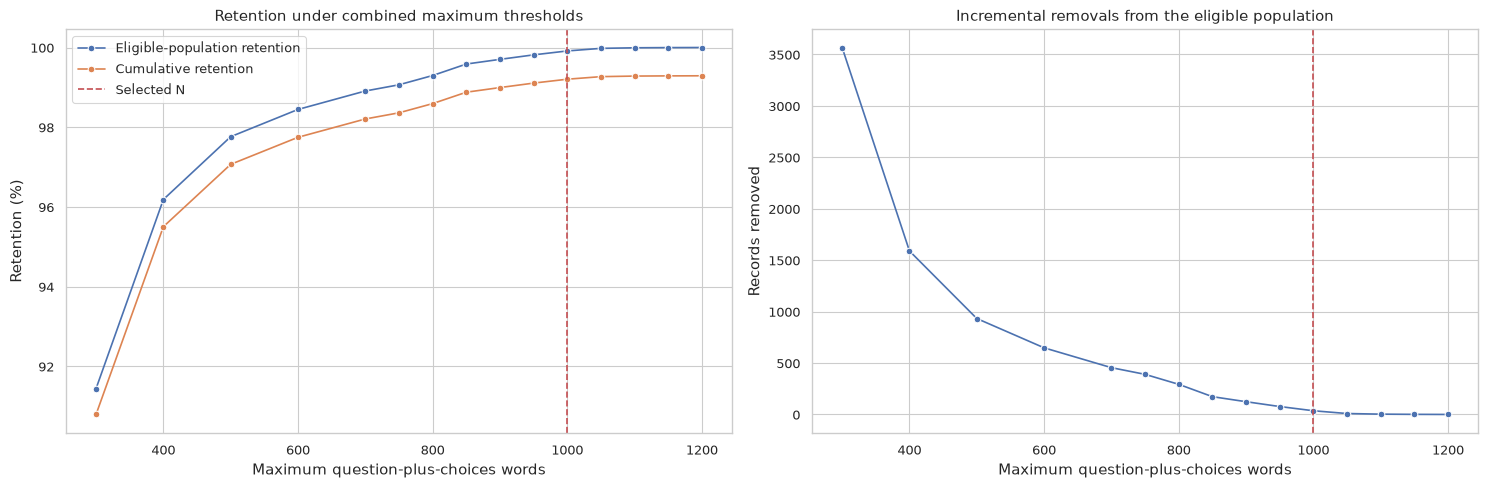

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.lineplot(data=total_ablation, x="max_total_words", y="eligible_retention_pct", marker="o", ax=axes[0], label="Eligible-population retention")
sns.lineplot(data=total_ablation, x="max_total_words", y="cumulative_retention_pct", marker="o", ax=axes[0], label="Cumulative retention")
axes[0].axvline(SELECTED_TOTAL_MAX_WORDS, color="#C44E52", linestyle="--", label="Selected N")
axes[0].set(title="Retention under combined maximum thresholds", xlabel="Maximum question-plus-choices words", ylabel="Retention (%)")
axes[0].legend()

sns.lineplot(data=total_ablation, x="max_total_words", y="incremental_removed", marker="o", ax=axes[1])
axes[1].axvline(SELECTED_TOTAL_MAX_WORDS, color="#C44E52", linestyle="--")
axes[1].set(title="Incremental removals from the eligible population", xlabel="Maximum question-plus-choices words", ylabel="Records removed")
plt.tight_layout()
plt.show()

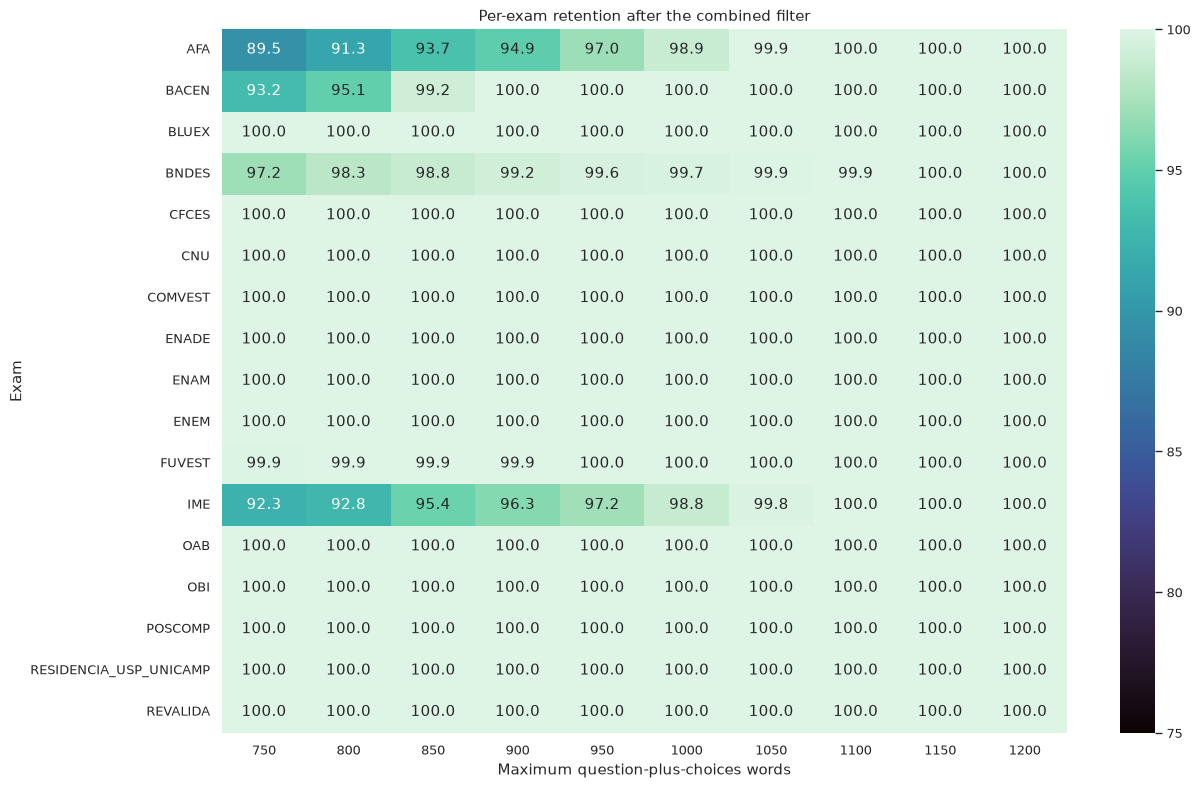

In [10]:
exam_retention = pd.DataFrame(
    {
        maximum: (
            eligible.loc[eligible["total_word_count"] <= maximum, "exam"]
            .value_counts()
            .reindex(baseline_exam_size.index, fill_value=0)
            / baseline_exam_size
            * 100
        )
        for maximum in CANDIDATE_THRESHOLDS
    }
).sort_index()

plt.figure(figsize=(13, 8))
sns.heatmap(exam_retention, annot=True, fmt=".1f", cmap="mako", vmin=75, vmax=100)
plt.title("Per-exam retention after the combined filter")
plt.xlabel("Maximum question-plus-choices words")
plt.ylabel("Exam")
plt.tight_layout()
plt.show()

## 5. Deterministic boundary audit

These deterministic samples cover adjacent regions around the selected N and nearby candidates. They support the interpretation of the selected operating point together with source-level retention.

In [11]:
def deterministic_sample(frame: pd.DataFrame, n: int = 8) -> pd.DataFrame:
    if frame.empty:
        return preview_table(frame)
    sampled = frame.sample(n=min(n, len(frame)), random_state=SEED)
    return preview_table(sampled.sort_values(["total_word_count", "exam"]))

boundary_bands = {
    "701–800 words": eligible[eligible["total_word_count"].between(701, 800)],
    "801–900 words": eligible[eligible["total_word_count"].between(801, 900)],
    "901–1,000 words": eligible[eligible["total_word_count"].between(901, 1_000)],
    "1,001–1,050 words": eligible[eligible["total_word_count"].between(1_001, 1_050)],
    "More than 1,050 words": eligible[eligible["total_word_count"] > 1_050],
}
for label, frame in boundary_bands.items():
    display(Markdown(f"### {label}: {len(frame):,} records"), deterministic_sample(frame))

### 701–800 words: 162 records

,exam,exam_edition,num,academic_level,question_word_count,choices_word_count,total_word_count,question_share,choice_word_counts,question,choices
36967,AFA,AFA_2021,39,high_school,594,117,711,0.835,"[25, 32, 31, 29]","TEXTO: TEXTO II A VERDADEIRA LEI DE GÉRSON Raul Marinho Gregorin Você se lembra daquele célebre comercial do cigarro Vila Rica, onde nosso tricampeão Gérson falava a famosa fra...",1. a Lei de Gérson evidenciou de modo contundente a natureza oportunista dos brasileiros da época das capitanias hereditári | 2. tanto o episódio envolvendo o carro da VW como ...
6788,BNDES,BNDES 2009 - Técnico em Arquivo,35,undergraduate,616,105,721,0.854,"[15, 19, 20, 20, 31]","Texto I EL PAÍS.com Deportes ""Adiós a nuestro complejo de perros callejeros"" Los brasileños consideran, como destaca Lula, que ya son ""ciudadanos respetados del mundo"" Tras las...","1. ""...los Juegos Olímpicos son más que un momento de fiesta deportiva,” (líneas 15 y 16) | 2. ""...representan la ocasión 'para que se amalgamen deportes, economía, educación, ..."
36436,AFA,AFA_2012,63,high_school,694,31,725,0.957,"[10, 10, 7, 4]","TEXTO: TEXT I BRAZILIAN AIR FORCE ACADEMY AFA (Air Force Academy), located at Pirassununga, State of São Paulo, is responsible for the training of Pilots, Administrative and Ae...","1. way to celebrate the importance of The Brazilian military schools. | 2. metaphor that describes the similarity among pilots, aircrafts and wings. | 3. comparison between a m..."
5705,BNDES,BNDES 2008 - Administração,24,undergraduate,713,32,745,0.957,"[10, 7, 5, 4, 6]",LA OCDE CUESTIONA LA ESCASA EFICIENCIA Y RENTABILIDAD DE LOS BIOCARBURANTES La Unión Europea se ha comprometido a que el 10% de sus combustibles serán biológicos para 2020 Laur...,1. baja significativa en el porcentaje de las emisiones de CO$_2$ | 2. amenaza para el medioambiente y la biodiversidad. | 3. destrucción de los ecosistemas naturales. | 4. con...
8083,BNDES,BNDES 2024 - Analista Administração (manhã),33,undergraduate,736,17,753,0.977,"[4, 3, 3, 3, 4]","Regeneration: Why businesses are moving beyond sustainability and thinking about regrowth Sustainability is out, regeneration is in. According to a 2019 survey by ReGenFriends,...",1. at the same time | 2. with different methods | 3. during asymmetric periods | 4. in specific opportunities | 5. on a daily basis
6292,BNDES,BNDES 2008 - Administração,28,undergraduate,669,89,758,0.883,"[16, 16, 22, 14, 21]","What are the best jobs of 2008? If you're job hunting in the professional or service-oriented fields, we have good news. Of the ten categories into which the Bureau of Labor St...","1. ""17 percent more employees..."" (lines 6-7) refers to employees in the construction, sales and administration categories. | 2. ""nearly double the expansion..."" (line 8) refer..."
7345,BNDES,BNDES 2011 - Técnico em Arquivo,32,undergraduate,703,79,782,0.899,"[15, 14, 16, 14, 20]","How to Avoid 7 Common On-the-Job Mistakes By HEATHER HUHMAN. June 17, 2US News Everyone makes mistakes — but some of those mistakes are more avoidable than others. When it come...",1. it is essential to wear new and expensive clothes at work to seem well off. | 2. co-workers are always asking for help in assignments they are not skilled to do. | 3. it is ...
7912,BNDES,BNDES 2013 - Administração,21,undergraduate,720,76,796,0.905,"[13, 16, 16, 14, 17]","Coworking: Sharing How We Work Genevieve DeGuzman Communication In the past, when trying to find places to work, independent workers, small businesses, and organizations often ...",1. convince people in different fields or specializations that they must work in pairs. | 2. suggest that coworking is an economic and socially stimulating alternative to boost...


### 801–900 words: 169 records

,exam,exam_edition,num,academic_level,question_word_count,choices_word_count,total_word_count,question_share,choice_word_counts,question,choices
36975,AFA,AFA_2021,47,high_school,791,13,804,0.984,"[4, 3, 3, 3]","TEXTO: TEXTO II A VERDADEIRA LEI DE GÉRSON Raul Marinho Gregorin Você se lembra daquele célebre comercial do cigarro Vila Rica, onde nosso tricampeão Gérson falava a famosa fra...","1. I, II e III | 2. II e III | 3. I e IV | 4. III e IV"
9506,IME,IME 2022 - Portugues,29,high_school,809,5,814,0.994,"[1, 1, 1, 1, 1]","Text 1 XAI-Explainable artificial intelligence Gunning, D., Stefik, M., Choi, J., Miller, T., Stumpf, S. e Yang, G-Z Recent successes in machine learning (ML) have led to a new...",1. perform | 2. disclose | 3. assess | 4. enhance | 5. acknowledge
3982,BACEN,Analista de Redes - Conhecimentos Gerais - 2006,12,undergraduate,714,105,819,0.872,"[17, 27, 20, 21, 20]","O segredo da acumulação primitiva neoliberal Numa coluna publicada na Folha de São Paulo, o jornalista Elio Gaspari evocava o drama recente de um navio de crianças escravas err...","1. Os sonhos de **cujos** nos queremos alimentar não satisfazem os desejos **com que** a eles nos moveram. | 2. A expressão de Elio Gaspari, **a qual** se refere o autor do tex..."
36610,AFA,AFA_2015,36,high_school,814,13,827,0.984,"[4, 4, 2, 3]","TEXTO: TEXT THE RELATIONSHIP BETWEEN FRIENDS AND TYPES OF 5 FRIENDSHIP Everyone has at least one best friend, some maybe even more. There are also those people who are just fri...",1. college and university atmosphere. | 2. Asperger and autism children. | 3. post-secondary-education friendships. | 4. researchers and friends.
3867,BACEN,Analista de Finanças - Conhecimentos Gerais - 2006,3,undergraduate,733,99,832,0.881,"[21, 22, 18, 16, 22]","O segredo da acumulação primitiva neoliberal Numa coluna publicada na Folha de São Paulo, o jornalista Elio Gaspari evocava o drama recente de um navio de crianças escravas err...","1. descarta a análise de processos históricos, para melhor se apoiar em aspectos da vida privada dos indivíduos típicos da | 2. mostra como as exigências de satisfação pessoal..."
36813,AFA,AFA_2019,3,high_school,751,85,836,0.898,"[21, 21, 22, 21]","TEXTO: TEXTO I Trecho da peça teatral A raposa e as uvas, escrita por Guilherme de Figueiredo. A cena ocorre na cidade de Samos (Grécia antiga), na casa de Xantós, um filósofo ...","1. Em ""Não te disse que trouxesse (...)?"", é possível perceber o coloquialismo no uso concomitante de 2ª e 3ª pessoas grama | 2. Em ""Por que só trazes língua?"", o pronome inter..."
3866,BACEN,Analista de Finanças - Conhecimentos Gerais - 2006,2,undergraduate,732,109,841,0.870,"[17, 27, 27, 25, 13]","O segredo da acumulação primitiva neoliberal Numa coluna publicada na Folha de São Paulo, o jornalista Elio Gaspari evocava o drama recente de um navio de crianças escravas err...","1. Massas inteiras se encontraram, assim, paradoxalmente livres da servidão, mas obrigadas a vender seu trabalho para sobre | 2. O navio tornava-se uma metáfora de toda a Áfric..."
36453,AFA,AFA_2012,80,high_school,819,58,877,0.934,"[15, 15, 14, 14]","TEXTO: TEXT II Why Bilinguals Are Smarter Speaking two languages rather than just one has obvious practical benefits in an increasingly globalized world. But in recent years, s...",1. if the fight between two simultaneously active language systems had improved these aspects of cognition. | 2. why does the fight between two simultaneously active language s...


### 901–1,000 words: 88 records

,exam,exam_edition,num,academic_level,question_word_count,choices_word_count,total_word_count,question_share,choice_word_counts,question,choices
2105,FUVEST,Fuvest 2015 - Primeira Fase),37,high_school,835,68,903,0.925,"[10, 17, 14, 14, 13]","TEXTO PARA AS QUESTÕES DE 37 A 39 O OPERÁRIO NO MAR Na rua passa um operário. Como vai firme! Não tem blusa. No conto, no drama, no discurso político, a dor do operário está na...","1. ""Para onde vai ele, (...)?"" = Aonde vai ele, (...)? | 2. ""O operário não lhe sobra tempo de perceber"" = Ao operário não lhe sobra tempo de perceber. | 3. ""Teria vergonha de ..."
8038,BNDES,BNDES 2013 - Técnico Administrativo,58,undergraduate,906,5,911,0.995,"[1, 1, 1, 1, 1]",Texto I Examen de conciencia en las escuelas de negocios Carmen Sánchez-Silva Las grandes escuelas de negocios también están sufriendo los efectos de la crisis. Dos terceras pa...,1. equivalente | 2. inadecuada | 3. indefinida | 4. opuesta | 5. paralela
36740,AFA,AFA_2017,45,high_school,906,13,919,0.986,"[3, 5, 3, 2]","TEXTO: FOOD SHORTAGE CAUSES, EFFECTS AND SOLUTIONS Food shortage is a serious problem facing the world and is prevalent in sub-Saharan Africa. The scarcity of food is caused by...",1. malnutrition and hunger. | 2. the increase of food prices. | 3. starvation and death. | 4. climatic changes.
7406,BNDES,BNDES 2011 - Engenheiro,25,undergraduate,901,22,923,0.976,"[5, 6, 4, 4, 3]",Texto I Wikileaks y la transparencia energética JAVIER GARCÍA BREVA 15/12/2010 Las filtraciones de Wikileaks[1] que están sacudiendo a la opinión pública mundial también hablan...,"1. diferenciar, variar, desunir o desviar. | 2. evitar un gasto o consumo mayor. | 3. exceder de lo debido. | 4. contravenir a lo razonable. | 5. quebrantar un precepto."
7411,BNDES,BNDES 2011 - Engenheiro,30,undergraduate,893,42,935,0.955,"[9, 9, 8, 8, 8]",Texto I Wikileaks y la transparencia energética JAVIER GARCÍA BREVA 15/12/2010 Las filtraciones de Wikileaks[1] que están sacudiendo a la opinión pública mundial también hablan...,1. el segundo presenta lenguaje informal con exceso de jergas. | 2. el enunciador del Texto I es neutro e imparcial. | 3. los dos presentan foco descriptivo de los objetos. | 4...
8958,IME,IME 2014 - Portugues,11,high_school,851,100,951,0.895,"[19, 26, 22, 11, 22]",Texto 2 A MULHER QUE NÃO SENTE MEDO DE ABSOLUTAMENTE NADA (Jeanna Bryner – Dezembro de 2010) Você gostaria de não sentir medo? Pelo menos uma pessoa no mundo não tem medo de na...,1. “...mas não **se** sabia se ela tinha a capacidade de sentir medo...” (texto2; 5º parágrafo)- conjunção subordinativa ad | 2. “...pode-**se** dizer que o sofrimento dela não...
9226,IME,IME 2018 - Portugues,17,high_school,951,25,976,0.974,"[5, 5, 5, 5, 5]","BECOS DE GOIÁS Beco da minha terra... Amo tua paisagem triste, ausente e suja. Teu ar sombrio. Tua velha umidade andrajosa. Teu lodo negro, esverdeado, escorregadio. E a réstia...","1. réstia, sifilítico, vê, grátis, baú | 2. água, família, há, revólver, frágil | 3. infância, matéria, à, móveis, saúva | 4. estória, poético, têm, viúva, maiúscula | 5. solit..."
36933,AFA,AFA_2021,4,high_school,944,51,995,0.949,"[16, 12, 15, 8]","TEXTO: TEXT When making a decision, it is a common impulse to look and see what others are doing. Nevertheless, it is often unclear whether the path that everyone else may be f...","1. the more people are in control of their choices, the better they can match their preferences. | 2. crowd following does not occur when people see that others are mistaken. |..."


### 1,001–1,050 words: 27 records

,exam,exam_edition,num,academic_level,question_word_count,choices_word_count,total_word_count,question_share,choice_word_counts,question,choices
9227,IME,IME 2018 - Portugues,18,high_school,985,16,1001,0.984,"[2, 2, 4, 4, 4]","BECOS DE GOIÁS Beco da minha terra... Amo tua paisagem triste, ausente e suja. Teu ar sombrio. Tua velha umidade andrajosa. Teu lodo negro, esverdeado, escorregadio. E a réstia...","1. I apenas. | 2. II apenas. | 3. I e III apenas. | 4. II e III apenas. | 5. I, II e III."
36795,AFA,AFA_2018,45,high_school,998,6,1004,0.994,"[1, 1, 3, 1]",TEXTO: TEXT WHY DO SUPERVILLAINS FASCINATE US? A PSYCHOLOGICAL PERSPECTIVE Why are we fascinated by supervillains? Posing the question is much like asking why evil itself intri...,1. harmful. | 2. unknown. | 3. unpleasant but true. | 4. impossible.
9407,IME,IME 2021 - Portugues,1,high_school,929,87,1016,0.914,"[24, 19, 15, 12, 17]","ENGENHEIROS DA VITÓRIA Solução de problemas na história [...] Quando se fala na eficiência em conseguir equipamentos de combate e transferir combatentes de A para B, os britâni...","1. foram iniciativas espontâneas realizadas pelo povo inglês, devido à sua familiaridade com o enfrentamento de situações d | 2. aconteceram devido à confiança dos dirigentes n..."
9341,IME,IME 2020 - Portugues,1,high_school,965,62,1027,0.940,"[12, 11, 12, 11, 16]","Texto 1 CAPÍTULO 3 A GUERRA DAS CAATINGAS Os doutores na arte de matar que hoje, na Europa, invadem escandalosamente a ciência, perturbando-lhe o remanso com um retinir de espo...",1. um conflito armado entre exércitos profissionais que se enfrentaram em campo aberto. | 2. uma guerra civil de soldados bem equipados e adaptados ao terreno. | 3. um conflito...
6298,BNDES,BNDES 2008 - Administração,24,undergraduate,994,35,1029,0.966,"[10, 6, 7, 6, 6]","Estilo casual La tendencia se afirma en las oficinas, pero con reglas La moda informal gana seguidores en las oficinas. Una tendencia que comenzó en Estados Unidos a fines de l...","1. ""En este banco se inició tímidamente..."" (líneas 24 y 25) | 2. ""...se implementa la política..."" (línea 32) | 3. ""...se brinda a los empleados..."" (línea 34) | 4. ""...los em..."
36788,AFA,AFA_2018,37,high_school,994,45,1039,0.957,"[12, 14, 8, 11]",TEXTO: TEXT WHY DO SUPERVILLAINS FASCINATE US? A PSYCHOLOGICAL PERSPECTIVE Why are we fascinated by supervillains? Posing the question is much like asking why evil itself intri...,1. the conscious knowledge that supervillains reinforce things we value (Pavlov and Skinner). | 2. the negative side people need to hide to grow as human beings (Carl Jung). | ...
9352,IME,IME 2020 - Portugues,12,high_school,975,65,1040,0.938,"[12, 18, 12, 7, 16]","Texto 1 CAPÍTULO 3 A GUERRA DAS CAATINGAS Os doutores na arte de matar que hoje, na Europa, invadem escandalosamente a ciência, perturbando-lhe o remanso com um retinir de espo...","1. ""(...) oferecendo a ambos a mesma penumbra às emboscadas (...)"" (linha 10). | 2. ""Lampeja por momentos entre os raios do sol joeirados pelas árvores sem folhas (...)"" (linha..."
36784,AFA,AFA_2018,33,high_school,995,49,1044,0.953,"[13, 11, 18, 7]",TEXTO: TEXT WHY DO SUPERVILLAINS FASCINATE US? A PSYCHOLOGICAL PERSPECTIVE Why are we fascinated by supervillains? Posing the question is much like asking why evil itself intri...,"1. We have to face and know ourselves deeply in order to become better. | 2. In fact, we are conditioned to expect more from the heroes. | 3. A psychological study states that ..."


### More than 1,050 words: 9 records

,exam,exam_edition,num,academic_level,question_word_count,choices_word_count,total_word_count,question_share,choice_word_counts,question,choices
8071,BNDES,BNDES 2024 - Analista Administração (manhã),21,undergraduate,989,62,1051,0.941,"[10, 14, 11, 15, 12]","O consumo como forma de expressão e de pertencimento Você é o que você consome, queira ou não, sendo consumista ou não. Dentro da lógica capitalista, a exemplo da frase dita pe...",1. definiram grupos urbanos em função do poder aquisitivo dos consumidores. | 2. inauguraram a compra e a venda de produtos como atividades de expressão de afeto. | 3. conceber...
8072,BNDES,BNDES 2024 - Analista Administração (manhã),22,undergraduate,991,75,1066,0.930,"[13, 12, 13, 18, 19]","O consumo como forma de expressão e de pertencimento Você é o que você consome, queira ou não, sendo consumista ou não. Dentro da lógica capitalista, a exemplo da frase dita pe...",1. redes sociais substituem hoje o lugar ocupado pelas lojas de departamentos no passado. | 2. novas tecnologias devem gerar futuramente mudanças rápidas na cultura consumista ...
36793,AFA,AFA_2018,43,high_school,996,73,1069,0.932,"[20, 16, 17, 20]",TEXTO: TEXT WHY DO SUPERVILLAINS FASCINATE US? A PSYCHOLOGICAL PERSPECTIVE Why are we fascinated by supervillains? Posing the question is much like asking why evil itself intri...,"1. Sigmund Freud viewed human nature as inherently antisocial, biologically driven by the undisciplined id's pleasure princ | 2. People who haven't met their most basic needs w..."
9489,IME,IME 2022 - Portugues,12,high_school,976,101,1077,0.906,"[19, 19, 17, 20, 26]","Texto 2 PENSAR A CIBERGUERRA A ideia de ciberguerra tem sido questionada por alguns estudiosos, tanto militares quanto civis. Para Thomas Rid, por exemplo, não houve até o mome...","1. a ciberguerra costuma acontecer em conflitos de baixa intensidade, nas ações de grupos como os zapatistas e o Hamas. | 2. a ciberguerra é um tipo de guerra não convencional ..."
8074,BNDES,BNDES 2024 - Analista Administração (manhã),24,undergraduate,989,95,1084,0.912,"[16, 23, 19, 17, 20]","O consumo como forma de expressão e de pertencimento Você é o que você consome, queira ou não, sendo consumista ou não. Dentro da lógica capitalista, a exemplo da frase dita pe...",1. a exposição de produtos em vitrines foi uma inovação das lojas de departamentos do século XIX. | 2. as mídias sociais servem como vitrines de vivências e experimentações de ...
8080,BNDES,BNDES 2024 - Analista Administração (manhã),30,undergraduate,972,129,1101,0.883,"[26, 29, 28, 24, 22]","O consumo como forma de expressão e de pertencimento Você é o que você consome, queira ou não, sendo consumista ou não. Dentro da lógica capitalista, a exemplo da frase dita pe...","1. primeiro parágrafo: ""Quem faz essa afirmação é o antropólogo Everardo Rocha, **que**, há cerca de 40 anos, estuda a Antr | 2. primeiro parágrafo: ""Em **seu** livro ‘O Paraís..."
8076,BNDES,BNDES 2024 - Analista Administração (manhã),26,undergraduate,977,144,1121,0.872,"[27, 30, 26, 27, 34]","O consumo como forma de expressão e de pertencimento Você é o que você consome, queira ou não, sendo consumista ou não. Dentro da lógica capitalista, a exemplo da frase dita pe...","1. Futuramente, em nossa sociedade, **haverão** constantes pressões para que as pessoas consumam cada vez mais, já que o su | 2. Alimentada pelo desejo de status e reconhecimen..."
8075,BNDES,BNDES 2024 - Analista Administração (manhã),25,undergraduate,979,181,1160,0.844,"[34, 39, 39, 33, 36]","O consumo como forma de expressão e de pertencimento Você é o que você consome, queira ou não, sendo consumista ou não. Dentro da lógica capitalista, a exemplo da frase dita pe...","1. A cultura do consumismo que se enraíza na sociedade moderna, faz com que indivíduos, influenciados por propagandas, rede | 2. As práticas consumistas e as estratégias de mar..."


In [12]:
candidate_comparison = total_ablation[
    total_ablation["max_total_words"].isin(CANDIDATE_THRESHOLDS)
].reset_index(drop=True)
display(Markdown("## 6. Candidate configurations"), candidate_comparison)

## 6. Candidate configurations

,max_total_words,retained_after_all_filters,incremental_removed,eligible_retention_pct,cumulative_retention_pct,high_school_retention_pct,undergraduate_retention_pct,worst_exam_retention_pct,worst_exam,max_exam_share_shift_pp
0,750,41300,390,99.065,98.361,98.047,99.379,89.517,AFA,0.254
1,800,41397,293,99.297,98.592,98.311,99.601,91.340,AFA,0.211
2,850,41517,173,99.585,98.878,98.830,99.818,93.710,AFA,0.155
3,900,41566,124,99.703,98.995,99.054,99.903,94.895,AFA,0.127
4,950,41613,77,99.815,99.107,99.390,99.947,96.992,AFA,0.074
5,1000,41654,36,99.914,99.205,99.756,99.962,98.763,IME,0.027
6,1050,41681,9,99.978,99.269,99.969,99.981,99.794,IME,0.012
7,1100,41687,3,99.993,99.283,100.000,99.991,99.926,BNDES,0.006
8,1150,41689,1,99.998,99.288,100.000,99.997,99.975,BNDES,0.002
9,1200,41690,0,100.000,99.290,100.000,100.000,100.000,ENADE,0.000


## 7. Threats to validity

1. **Sequential conditioning.** Results describe the population that already passed the question and choice filters, not the full structurally valid dataset.
2. **No semantic labels.** Combined length is not equivalent to quality; long passages and verbose alternatives can be valid.
3. **Question dominance.** Question length explains most combined-length variation, so source effects may resemble the question-only ablation.
4. **No downstream evaluation.** This study does not measure model accuracy, calibration, latency, or tokenizer-specific context use.
5. **Whitespace-based words.** The Curator metric reproduces pipeline behavior but is not a model tokenizer; tables and formulas can behave differently.
6. **Source imbalance.** Large exams dominate aggregate results, so subgroup retention and boundary samples must accompany global retention.

In [13]:
metrics_by_threshold = total_ablation.set_index("max_total_words")
selected = metrics_by_threshold.loc[SELECTED_TOTAL_MAX_WORDS]
selected_removed = eligible[eligible["total_word_count"] > SELECTED_TOTAL_MAX_WORDS]
removed_by_exam = selected_removed["exam"].value_counts().sort_index()
removed_by_exam_text = ", ".join(f"{exam}: {count:,}" for exam, count in removed_by_exam.items())
p99 = eligible["total_word_count"].quantile(0.99)
p995 = eligible["total_word_count"].quantile(0.995)
p999 = eligible["total_word_count"].quantile(0.999)

display(
    Markdown(
        f"""## 8. Conclusion and selected operating point

- Structurally valid input: **{len(data):,} records**.
- After the inclusive 4–1,000 word question filter: **{int(question_mask.sum()):,} records**.
- After the inclusive 300-word choices filter: **{len(eligible):,} records**; this is the baseline for N.
- Combined-length median: **{eligible['total_word_count'].median():,.0f} words**.
- Upper-tail percentiles: **p99={p99:,.1f}**, **p99.5={p995:,.1f}**, and **p99.9={p999:,.1f} words**.
- Observed eligible range: **{eligible['total_word_count'].min():,}–{eligible['total_word_count'].max():,} words**.
- The selected inclusive threshold is **N={SELECTED_TOTAL_MAX_WORDS:,} words**, just above p99.9.
- It retains **{int(selected['retained_after_all_filters']):,} of {len(eligible):,} eligible records ({selected['eligible_retention_pct']:.3f}%)** and removes **{int(selected['incremental_removed']):,}**.
- Cumulative retention from the structurally valid input is **{selected['cumulative_retention_pct']:.3f}%**.
- Retention is **{selected['high_school_retention_pct']:.3f}%** for high-school questions and **{selected['undergraduate_retention_pct']:.3f}%** for undergraduate questions.
- The least-retained exam is **{selected['worst_exam']} ({selected['worst_exam_retention_pct']:.3f}%)**; removals by exam are {removed_by_exam_text}.
- The maximum change in exam prevalence is **{selected['max_exam_share_shift_pp']:.3f} percentage points**.

The final sequential policy is:

    4 <= question_word_count <= 1,000
    choices_word_count <= 300
    total_word_count <= 1,000

The boundary audit indicates that many excluded records are legitimate passage-based questions. The combined threshold is therefore an operational size-control policy, not evidence that records above it are semantically invalid."""
    )
)

## 8. Conclusion and selected operating point

- Structurally valid input: **41,988 records**.
- After the inclusive 4–1,000 word question filter: **41,731 records**.
- After the inclusive 300-word choices filter: **41,690 records**; this is the baseline for N.
- Combined-length median: **137 words**.
- Upper-tail percentiles: **p99=727.1**, **p99.5=836.0**, and **p99.9=992.3 words**.
- Observed eligible range: **9–1,160 words**.
- The selected inclusive threshold is **N=1,000 words**, just above p99.9.
- It retains **41,654 of 41,690 eligible records (99.914%)** and removes **36**.
- Cumulative retention from the structurally valid input is **99.205%**.
- Retention is **99.756%** for high-school questions and **99.962%** for undergraduate questions.
- The least-retained exam is **IME (98.763%)**; removals by exam are AFA: 12, BNDES: 12, IME: 12.
- The maximum change in exam prevalence is **0.027 percentage points**.

The final sequential policy is:

    4 <= question_word_count <= 1,000
    choices_word_count <= 300
    total_word_count <= 1,000

The boundary audit indicates that many excluded records are legitimate passage-based questions. The combined threshold is therefore an operational size-control policy, not evidence that records above it are semantically invalid.